In [3]:
import pandas as pd
pd.__version__
print(pd.__name__)

pandas


 Начнём наше знакомство с библиотекой Pandas со структуры данных pandas.Series (серия, ряд). 
 Series — это упорядоченная изменяемая коллекция объектов, имеющая так называемые ассоциативные метки (индексы). 
 Эту структуру можно сравнить со списком: каждому элементу ставится в соответствие индекс, однако, в отличие от списка, индексами могут быть не только порядковые номера — фактически что угодно, например названия компаний, даты, идентификаторы, наименования продуктов.

Также для каждой Series присваивается тип данных её элементов (например int64) и может быть определено имя всего массива. В итоге мы получаем некоторый гибрид списка и словаря.

In [7]:
#Способ 1 - из списка

countries = pd.Series(
    data = ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ'],
    name = 'countries'
)
display(countries)

UK       Англия
CA       Канада
US          США
RU       Россия
UA      Украина
BY     Беларусь
KZ    Казахстан
Name: countries, dtype: object

In [5]:
#Примечание. Если оставить параметр index пустым, то метки будут присвоены автоматически в виде порядковых номеров элементов, например:
countries = pd.Series(
    ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан']
)
display(countries)

0       Англия
1       Канада
2          США
3       Россия
4      Украина
5     Беларусь
6    Казахстан
dtype: object

In [6]:
#Cпособ 2 из словаря :

countries = pd.Series({
    'UK': 'Англия',
    'CA': 'Канада',
    'US' : 'США',
    'RU': 'Россия',
    'UA': 'Украина',
    'BY': 'Беларусь',
    'KZ': 'Казахстан'},
    name = 'countries'
)
display(countries)

UK       Англия
CA       Канада
US          США
RU       Россия
UA      Украина
BY     Беларусь
KZ    Казахстан
Name: countries, dtype: object

Доступ к данным в Series
Доступ к элементам осуществляется с использованием loc или iloc.

.loc вызывается с квадратными скобками, в которые передаются метки. В него можно передать как один индекс, так и список, чтобы получилось несколько элементов. 

Например, для получения названия страны по коду "US" можно выполнить следующий код:

print(countries.loc['US'])
# США
Для того чтобы достать информацию по нескольким индексам, необходимо обернуть интересующие индексы в список:

print(countries.loc[['US', 'RU', 'UK']])


_______________
.iloc также вызывается с квадратными скобками и принимает на вход порядковые номера элементов Series (нумерация начинаются с 0). В него можно так же передавать как один индекс, так и диапазон чисел. 

Например, для получения элемента по индексу "KZ" нужно обратиться через .iloc по номеру 6:

print(countries.iloc[6])
# Казахстан
Получим срез из исходной Series с первого по третий элемент:

print(countries.iloc[1:4])

DataFrame как структура данных
DataFrame является двумерной структурой и представляется в виде таблицы, в которой есть строки и столбцы: столбцами в DataFrame выступают объекты Series, а строки формируются из их элементов. Также в DataFrame есть метки (индексы), которые соответствуют каждой строке таблицы.

На самом деле loc и iloc можно опустить и обращаться к элементам Series напрямую по индексам, например countries[[‘UK’, 'US', ‘UA’]] или countries[[0, 2, 4]]. Оба варианта являются равноправными для Series, однако в дальнейшем мы будем использовать эти операции при обращении к более сложной структуре — DataFrame, а в контексте этой структуры эти варианты уже неравноправны.

В дальнейшем слова DataFrame и таблица будут употребляться как синонимы. Также синонимами в Data Science являются слова столбец таблицы и признак.
Создание DataFrame

DataFrame создаётся с помощью функции pd.DataFrame(). Так же, как и для Series, для создания объектов DataFrame есть несколько способов:
Способ 1

Самый простой способ создания DataFrame — из словаря, ключами которого являются имена столбцов будущей таблицы, а значениями — списки, в которых хранится содержимое этих столбцов:

countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24, 45.5, 9.5, 17.04],
    'area': [133396, 9984670, 9826630, 17125191, 603628, 207600, 2724902]
})
Обратите внимание, что, так как мы не задали метки (индексы) DataFrame, они были сгенерированы автоматически. Исправим это, задав индексы вручную:

countries_df.index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ']
display(countries_df)

Способ 2

Также DataFrame можно создать из вложенного списка, внутренние списки которого будут являться строками новой таблицы:

countries_df = pd.DataFrame(
    data = [
        ['Англия', 56.29, 133396],
        ['Канада', 38.05, 9984670],
        ['США', 322.28, 9826630],
        ['Россия', 146.24, 17125191],
        ['Украина', 45.5, 603628],
        ['Беларусь', 9.5, 207600],
        ['Казахстан', 17.04, 2724902]
    ],
    columns= ['country', 'population', 'area'],
    index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ']
)
display(countries_df)

Axis в DataFrame

Например, мы можем удалять как строки, так и столбцы таблицы, вычислять среднее значение как по столбцам, так и по строкам таблицы.

При работе с Pandas важно уметь указывать направление работы метода, который используется. Для этого вводится понятие axis (ось, координата). Движение по строкам в таблице обозначается axis с индексом 0, а движение по столбцам — axis с индексом 1.

Данный параметр заложен во все методы, которые могут работать в двух направлениях и по умолчанию в большинстве из них axis=0, то есть они выполняют операции со строками, если не задавать axis вручную.


In [ ]:
from IPython.display import Image
Image(url='https://lms.skillfactory.ru/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block@dst3-u1-md10_3_4.png')


Рассмотрим разницу в результатах работы методов в зависимости от параметра axis на примере использования метода DataFrame mean() — вычисление среднего по таблице.

Считаем среднее по строкам (axis = 0) в каждом столбце:

countries_df.mean(axis=0, numeric_only=True)


В данном случае среднее было рассчитано по строкам для столбцов population и area.

Обратите внимание на то, что так как не все столбцы в нашей таблице являются числовыми, то нам необходимо установить параметр numeric_only в значение True (вести расчёт только по числовым столбцам). Это делается для того, чтобы не получать предупреждений (warnings).

Считаем среднее по столбцам (axis = 1) в каждой строке:

countries_df.mean(axis=1, numeric_only=True)
Img

Здесь среднее было рассчитано по числовым столбцам для каждой строки в таблице.

In [10]:
countries_df = pd.DataFrame(
    data = [
        ['Англия', 56.29, 133396],
        ['Канада', 38.05, 9984670],
        ['США', 322.28, 9826630],
        ['Россия', 146.24, 17125191],
        ['Украина', 45.5, 603628],
        ['Беларусь', 9.5, 207600],
        ['Казахстан', 17.04, 2724902]
    ],
    columns= ['country', 'population', 'area'],
    index = ['UK', 'CA', 'US', 'RU', 'UA', 'BY', 'KZ']
)
display(countries_df)

,country,population,area
UK,Англия,56.29,133396
CA,Канада,38.05,9984670
US,США,322.28,9826630
RU,Россия,146.24,17125191
UA,Украина,45.50,603628
BY,Беларусь,9.50,207600
KZ,Казахстан,17.04,2724902


In [22]:
import pandas as pd

income = [478, 512, 196]
expenses = [156, 130, 270]
years = [2018, 2019, 2020]

kekw = pd.DataFrame({
    'Income': income,
    'Expenses': expenses
}, index=years)
    
display(kekw)

,Income,Expenses
2018,478,156
2019,512,130
2020,196,270


In [ ]:
#Считаем среднее по строкам (axis = 0) в каждом столбце:
countries_df.mean(axis=0, numeric_only=True)

population    9.070000e+01
area          5.800860e+06
dtype: float64

In [12]:
#Считаем среднее по столбцам (axis = 1) в каждой строке:
countries_df.mean(axis=1, numeric_only=True)

UK      66726.145
CA    4992354.025
US    4913476.140
RU    8562668.620
UA     301836.750
BY     103804.750
KZ    1362459.520
dtype: float64

Доступ к данным в DataFrame

In [13]:
#Способ 1 Можно обратиться к DataFrame по имени столбца через точку:
countries_df.population

UK     56.29
CA     38.05
US    322.28
RU    146.24
UA     45.50
BY      9.50
KZ     17.04
Name: population, dtype: float64

In [14]:
#Способ 2 Другой вариант — обратиться к DataFrame по индексу и указать имя столбца:
countries_df['population']

UK     56.29
CA     38.05
US    322.28
RU    146.24
UA     45.50
BY      9.50
KZ     17.04
Name: population, dtype: float64

Примечание. Обратите внимание, что, как и ожидалось, при обращении к столбцу DataFrame мы получаем объект Series с именем, соответствующим имени столбца. Удостовериться в этом можно с помощью функции type():

type(countries_df.population)
# pandas.core.series.Series

Для того чтобы получить доступ к ячейкам таблицы, используются уже знакомые нам loc и iloc.
При этом, в соответствии с механизмом работы axis, при обращении к DataFrame по индексам с помощью loc (iloc) первым индексом указывается индекс (порядковый номер), соответствующий строкам, а вторым — имя (порядковый номер) столбца.

In [16]:
#Получим площадь Великобритании:


countries_df.loc['UK', 'area']

np.int64(133396)

In [17]:
#Получим население и площадь, соответствующие России:
countries_df.loc['RU', ['population', 'area']]

population      146.24
area          17125191
Name: RU, dtype: object

In [18]:
#Сделаем вырезку из таблицы и получим информацию о населении и площади, соответствующую Украине, Беларуси и Казахстану:
countries_df.loc[['UA', 'BY', 'KZ'],['population', 'area']]

,population,area
UA,45.50,603628
BY,9.50,207600
KZ,17.04,2724902


In [19]:
#или
countries_df.iloc[4:8, 1:3]

,population,area
UA,45.50,603628
BY,9.50,207600
KZ,17.04,2724902


In [ ]:

import pandas as pd




income = [478, 512, 196]
expenses = [156, 130, 270]
years = [2018, 2019, 2020]


def create_companyDF(income, expenses, years):
    df = pd.DataFrame({'Income': income,'Expenses': expenses}, index=years)
    return df
def get_profit(df,year):
    if year not in df.index:
        return None
    income = df.loc[year, 'Income']
    expenses = df.loc[year, 'Expenses']
    profit = income - expenses
    print(f"Income: {income}")
    print(f"expenses: {expenses}")
    return profit

print(get_profit(year = 2018, df = create_companyDF([612, 516, 329, 158], [136,163,250,361], [2017,2018,2019,2020])))

Запись в csv-файл
Экспорт данных в формат csv осуществляется с помощью метода DataFrame to_csv().  
path_or_buf — путь до файла, в который будет записан DataFrame (например, data/my_data.csv)
sep — разделитель данных в выходном файле (по умолчанию ',');
decimal — разделитель чисел на целую и дробную части в выходном файле (по умолчанию '.');
columns — список столбцов, которые нужно записать в файл (по умолчанию записываются все столбцы);
index — параметр, определяющий, требуется ли создавать дополнительный столбец с индексами строк в файле (по умолчанию True).

In [23]:
countries_df = pd.DataFrame({
    'country': ['Англия', 'Канада', 'США', 'Россия', 'Украина', 'Беларусь', 'Казахстан'],
    'population': [56.29, 38.05, 322.28, 146.24, 45.5, 9.5, 17.04],
    'area': [133396, 9984670, 9826630, 17125191, 603628, 207600, 2724902]
})

countries_df.to_csv('data/countries.csv', index=False, sep=';')

Чтение csv-файла
read_csv()
filepath_or_buffer — путь до файла, который мы читаем;
sep — разделитель данных (по умолчанию ',');
decimal — разделитель чисел на целую и дробную часть в выходном файле (по умолчанию '.');
names — список с названиями столбцов для чтения;
skiprows — количество строк в файле, которые нужно пропустить (например, файл может содержать служебную информацию, которая нам не нужна).


In [24]:
countries_data = pd.read_csv('data/countries.csv', sep=';')
display(countries_data)

,country,population,area
0,Англия,56.29,133396
1,Канада,38.05,9984670
2,США,322.28,9826630
3,Россия,146.24,17125191
4,Украина,45.50,603628
5,Беларусь,9.50,207600
6,Казахстан,17.04,2724902


Чтение csv-файла по ссылке
его можно прочитать и из интернета — для этого достаточно в функции read_csv() вместо пути до файла указать ссылку на файл

In [25]:
data = pd.read_csv('https://raw.githubusercontent.com/esabunor/MLWorkspace/master/melb_data.csv')
display(data)

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18391,23540,Williamstown,8/2 Thompson St,2,t,622500.0,SP,Greg,26/08/2017,6.8,...,2.0,1.0,NaN,89.0,2010.0,NaN,-37.86393,144.90484,Western Metropolitan,6380.0
18392,23541,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0
18393,23544,Yallambie,17 Amaroo Wy,4,h,1100000.0,S,Buckingham,26/08/2017,12.7,...,3.0,2.0,NaN,NaN,NaN,NaN,-37.72006,145.10547,Northern Metropolitan,1369.0
18394,23545,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,...,1.0,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0


Запись и чтение в других форматах

Методы для записи таблиц в файлы отличных от csv форматов:
to_excel() — запись DataFrame в формат Excel-таблицы (.xlsx);
to_json() — запись DataFrame в формат JSON (.json);
to_xml() — запись DataFrame в формат XML-документа (.xml);
to_sql() — запись DataFrame в базу данных SQL (для реализации этого метода необходимо установить соединение с базой данных).

Методы для чтения таблиц из файлов в отличных от csv форматах:
read_excel() — чтение из формата Excel-таблицы (.xlsx) в DataFrame;
read_json() — чтение из формата JSON (.json) в DataFrame;
read_xml() — чтение из формата XML-документа (.xml) в DataFrame;
read_sql() — чтение из базы данных SQL в DataFrame (также необходимо установить соединение с базой данных).

Прочитаем наши данные о недвижимости из csv-файла и запишем результирующий DataFrame в переменную melb_data:

In [49]:
melb_data = pd.read_csv('data/melb_data.csv', sep=',')
x = melb_data.loc[3521, ['Landsize']]
y = melb_data.loc[1690, ['Landsize']]
z = round(float(x/y))

z

C:\Users\Denlex\AppData\Local\Temp\ipykernel_17176\2027537076.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  z = round(float(x/y))


3

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\Denlex\AppData\Local\Temp\ipykernel_17176\1143350092.py:2: SyntaxWarning: invalid escape sequence '\I'
  Image('C:\IDE\Pandas ВВедение\data\data_png.png')


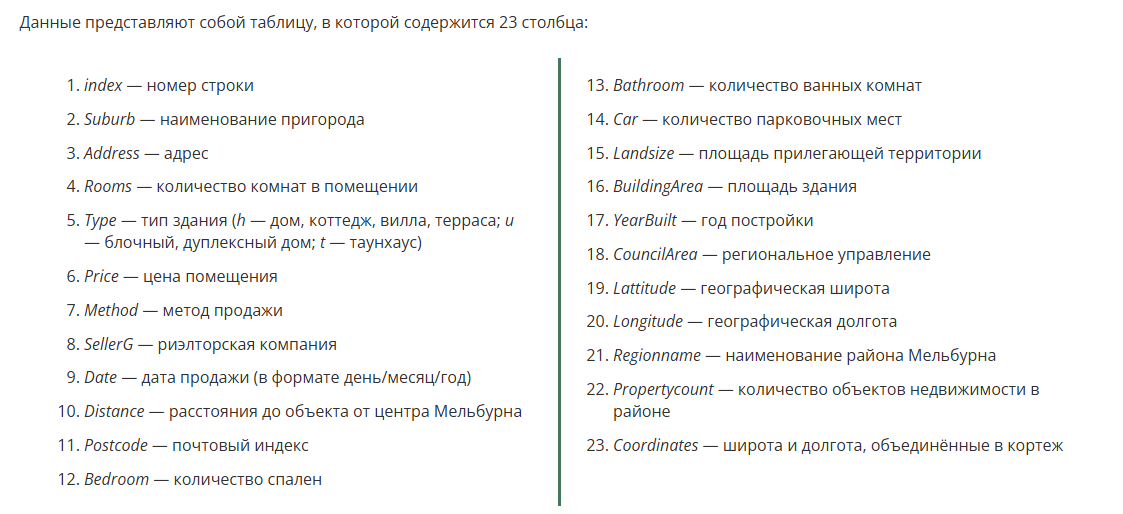

In [28]:
from IPython.display import Image
Image('C:\IDE\Pandas ВВедение\data\data_png.png')

Вывод первых и последних строк
 Часто бывает такое, что вывести на экран все строки таблицы является ресурсозатратной операцией, а иногда и вовсе не представляется возможным. В большинстве случаев для того, чтобы понять структуру DataFrame и удостовериться, что таблица подгрузилась верно, достаточно вывести несколько первых или последних строк.
 Для этого у DataFrame есть методы head() и tail(), которые возвращают n первых и n последних строк таблицы соответственно (по умолчанию n = 5).
 Выведем первые пять строк нашей таблицы:

In [50]:
display(melb_data.head())

,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Coordinates
0,0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,202.0,126.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,"-37.7996, 144.9984"
1,1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,"-37.8079, 144.9934"
2,2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,"-37.8093, 144.9944"
3,3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,1.0,94.0,126.0,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,"-37.7969, 144.9969"
4,4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,"-37.8072, 144.9941"


In [51]:
melb_data.tail(7)

,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Coordinates
13573,13573,Werribee,5 Nuragi Ct,4,h,635000.0,S,hockingstuart,26/08/2017,14.7,...,1.0,662.0,172.0,1980.0,NaN,-37.89327,144.64789,Western Metropolitan,16166.0,"-37.89327, 144.64789"
13574,13574,Westmeadows,9 Black St,3,h,582000.0,S,Red,26/08/2017,16.5,...,2.0,256.0,126.0,1970.0,NaN,-37.67917,144.89390,Northern Metropolitan,2474.0,"-37.67917, 144.8939"
13575,13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,...,2.0,652.0,126.0,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0,"-37.90562, 145.16761"
13576,13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,...,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0,"-37.85927, 144.87904"
13577,13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,...,4.0,436.0,126.0,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0,"-37.85274, 144.88738"
13578,13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,...,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0,"-37.85908, 144.89299"
13579,13579,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,...,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0,"-37.81188, 144.88449"


Размерность таблицы
Далее хотелось бы узнать размер таблицы — количество строк и количество столбцов. Это можно сделать с помощью атрибута shape, который возвращает кортеж с количеством строк и столбцов:

In [ ]:
melb_data.shape
#Таким образом, в наших данных содержится информация о 13 580 объектах недвижимости, и их описывают 23 признака.

(13580, 23)

Получение информации о столбцах
Для того чтобы получить более детальную информацию о столбцах таблицы, можно использовать метод DataFrame info():

In [53]:
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          13580 non-null  int64  
 1   Suburb         13580 non-null  object 
 2   Address        13580 non-null  object 
 3   Rooms          13580 non-null  int64  
 4   Type           13580 non-null  object 
 5   Price          13580 non-null  float64
 6   Method         13580 non-null  object 
 7   SellerG        13580 non-null  object 
 8   Date           13580 non-null  object 
 9   Distance       13580 non-null  float64
 10  Postcode       13580 non-null  int64  
 11  Bedroom        13580 non-null  float64
 12  Bathroom       13580 non-null  float64
 13  Car            13580 non-null  float64
 14  Landsize       13580 non-null  float64
 15  BuildingArea   13580 non-null  float64
 16  YearBuilt      13580 non-null  float64
 17  CouncilArea    12211 non-null  object 
 18  Lattit

Данный метод выводит:

информацию об индексах;
информацию об общем количестве столбцов;
таблицу, в которой содержится информация об именах столбцов (Column), количестве непустых значений (Non-Null Count) в каждом столбце и типе данных столбца (Dtype), количестве столбцов, в которых используется определённый тип данных;
количество оперативной памяти в мегабайтах, которое тратится на хранение данных.

Из вывода метода info() становится понятно, что в нашей таблице есть столбец CouncilArea с пропущенными значениями — количество непустых значений в столбце меньше, чем количество строк в таблице (12211 < 13580).

Пустыми, или пропущенными, значениями называются значения в ячейках таблицы, которые не заполнены по какой-либо причине, то есть на их месте стоит пустое место. В Pandas такие значения обозначаются символом NaN (Not-a-Number).

→ Мы будем говорить о работе с пропусками в отдельном модуле, посвящённом очистке данных, а пока что не будем обращать на них внимания.

Если вам всё же любопытно, как можно работать с такими значениями в Pandas, то вы можете посмотреть информацию здесь

Изменение типа данных в столбце
Если присмотреться внимательнее к выводу метода info(), а конкретнее — к типам данных столбцов, становится понятно, что некоторые признаки кодируются не совсем корректными типами данных. 
Например, данные в столбцах, которые отражают количество, должны, по идее, выражаться целым числом (Car, Bedroom, Bathroom и Propertyсount), однако кодируются float64 — числом с плавающей запятой размером 64 бита.

Наконец, данные в столбце с годом постройки (YearBuilt) также представлены в формате чисел с плавающей точкой.

Чтобы исправить это, можно воспользоваться методом astype(), который позволяет преобразовать тип данных столбца:

In [54]:
melb_data['Car'] = melb_data['Car'].astype('int64')
melb_data['Bedroom'] = melb_data['Bedroom'].astype('int64')
melb_data['Bathroom'] = melb_data['Bathroom'].astype('int64')
melb_data['Propertycount'] = melb_data['Propertycount'].astype('int64')
melb_data['YearBuilt'] = melb_data['YearBuilt'].astype('int64')
melb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          13580 non-null  int64  
 1   Suburb         13580 non-null  object 
 2   Address        13580 non-null  object 
 3   Rooms          13580 non-null  int64  
 4   Type           13580 non-null  object 
 5   Price          13580 non-null  float64
 6   Method         13580 non-null  object 
 7   SellerG        13580 non-null  object 
 8   Date           13580 non-null  object 
 9   Distance       13580 non-null  float64
 10  Postcode       13580 non-null  int64  
 11  Bedroom        13580 non-null  int64  
 12  Bathroom       13580 non-null  int64  
 13  Car            13580 non-null  int64  
 14  Landsize       13580 non-null  float64
 15  BuildingArea   13580 non-null  float64
 16  YearBuilt      13580 non-null  int64  
 17  CouncilArea    12211 non-null  object 
 18  Lattit

Получение описательной статистики

 Часто при работе с таблицей нужно быстро посмотреть на основные статистические свойства её столбцов. Для этого можно воспользоваться методом DataFrame describe().
 По умолчанию метод работает с числовыми (int64 и float64) столбцами и показывает число непустых значений (count), среднее (mean), стандартное отклонение (std), минимальное значение (min),  квантили уровней 0.25, 0.5 (медиана) и 0.75 (25%, 50%, 75%) и максимальное значение (max) для каждого столбца исходной таблицы.
 Чтобы не увязнуть в обилии информации, выведем на экран значение статистических параметров только для столбцов Distance (расстояние от объекта недвижимости до центра Мельбурна), BuildingArea (площадь здания) и Price (цена объекта):

In [55]:
melb_data.describe().loc[:, ['Distance', 'BuildingArea' , 'Price']]

,Distance,BuildingArea,Price
count,13580.000000,13580.000000,1.358000e+04
mean,10.137776,139.633972,1.075684e+06
std,5.868725,392.217403,6.393107e+05
min,0.000000,0.000000,8.500000e+04
25%,6.100000,122.000000,6.500000e+05
50%,9.200000,126.000000,9.030000e+05
75%,13.000000,129.940000,1.330000e+06
max,48.100000,44515.000000,9.000000e+06


Какие интересные выводы мы можем сделать, исходя из построенной таблицы?

Столбец Distance (расстояние до центра города)
В нашем наборе данных представлены объекты, удалённые от центра города на расстояние до 48 километров.

Столбец BuildingArea (площадь здания)
В нашей таблице представлены участки, на которых отсутствует само здание (его площадь равна 0), то есть владельцы продавали участок земли без строений на нём.
Большая часть объектов (75%) имеет площадь здания до 130 квадратных метров, однако в нашей таблице есть настоящий дворец (судя по его размерам) с площадью в 44 515 квадратных метров.

Столбец Price (цена)
Диапазон цен на недвижимость в Мельбурне варьируется от 85 тысяч до 9 миллионов австралийских долларов.

На самом деле метод describe() можно применять не только к числовым признакам. С помощью параметра include можно указать тип данных, для которого нужно вывести описательную информацию.

Например, для типа данных object метод describe() возвращает DataFrame, в котором указаны:
количество непустых строк (count);
количество уникальных значений (unique);
самое частое значение — мода —  (top);
частота — объём использования — этого значения (freq) для каждого столбца типа object исходной таблицы.

In [56]:
melb_data.describe(include=['object'])

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname,Coordinates
count,13580,13580,13580,13580,13580,13580,12211,13580,13580
unique,314,13378,3,5,268,58,33,8,13097
top,Reservoir,5 Charles St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan,"-37.8361, 144.9966"
freq,359,3,9449,9022,1565,473,1163,4695,12


Также приведём несколько выводов, которые можно сделать из полученной таблицы:

Столбец Suburb (пригород)
Наибольшее количество проданных объектов (359) находилось в пригороде Reservoir.

Столбец Type (тип здания)
Самый популярный тип дома — h (дом, вилла, коттедж).

Столбец SellerG (риелтор)
В наших данных нам известно о 268 различных риэлторских компаниях, однако самой главной «акулой» в этом бизнесе является компания Nelson — они продали 1 565 различных домов.

Столбец Date (дата продажи)
В нашей таблице содержится информация за 58 дней, при этом наибольшее число продаж (473) пришлось на 27 мая 2017 года.

Получение частоты уникальных значений в столбце

Для того чтобы определить, сколько раз в столбце повторяется каждый из вариантов значений (т.е. найти частоту для каждого уникального знания), используется метод value_counts().

Данный метод возвращает объект Series, в котором в качестве индексов выступают уникальные категории столбца, а значениями — соответствующая им частота.

Рассмотрим работу value_counts() на примере столбца с названиями районов:

In [64]:
melb_data['Suburb'].value_counts()

Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
                 ... 
Attwood             1
Wallan              1
New Gisborne        1
Plumpton            1
Monbulk             1
Name: count, Length: 314, dtype: int64

In [63]:
melb_data['CouncilArea'].isna().sum()

#Ключевые методы: isna() или isnull() - возвращает булеву маску (True для пропусков)

#sum() - подсчитывает количество True значений

np.int64(1369)

Чтобы сделать вывод более интерпретируемым и понятным, можно воспользоваться параметром normalize. 
При установке значения этого параметра на True результат будет представляться в виде доли (относительной частоты):

In [58]:
melb_data['Regionname'].value_counts(normalize=True)

Regionname
Southern Metropolitan         0.345729
Northern Metropolitan         0.286451
Western Metropolitan          0.217084
Eastern Metropolitan          0.108321
South-Eastern Metropolitan    0.033137
Eastern Victoria              0.003903
Northern Victoria             0.003019
Western Victoria              0.002356
Name: proportion, dtype: float64

In [ ]:
#Сколько процентов от общего количества домов составляют таунхаусы (тип объекта — t)?
percentage = (melb_data['Type'].value_counts(normalize=True).get('t', 0) * 100)
percentage

np.float64(8.203240058910161)

Агрегирующие методы

 Мы научились выводить информацию о статистических показателях с помощью метода describe(). Однако этот метод становится не очень удобным, когда необходимо найти только один статистический параметр, например только среднюю цену,  и использовать их в дальнейшем коде. Поэтому в Pandas предусмотрены инструменты быстрого вычисления показателей с помощью агрегирующих методов. 

Агрегирующим в Pandas называется метод, который для каждого столбца возвращает только одно значение — показатель (например, вычисление медианы, максимума, среднего и так далее).

Метод	Статистический параметр
.count()	Количество непустых значений
.mean()	Среднее значение
.min()	Минимальное значение
.max()	Максимальное значение
.var()	Дисперсия
.std()	Стандартное отклонение
.sum()	Сумма
.quantile(x)	Квантиль уровня x
.nunique()	Число уникальных значений

В каждый метод можно передать некоторые параметры, среди которых:

axis  — определяет, подсчитывать параметр по строкам или по столбцам;
numeric_only — определяет, вычислять параметры только по числовым столбцам/строкам или нет (True/False).

In [67]:
#Вычислим среднюю цену на объекты недвижимости:
print(melb_data['Price'].mean())

1075684.079455081


In [73]:
#Найдём максимальное количество парковочных мест:
print(melb_data['Propertycount'].max())

21650


In [69]:
#А теперь представим, что риэлторская ставка для всех компаний за продажу недвижимости составляет 12%. 
# Найдём общую прибыльность риэлторского бизнеса в Мельбурне. Результат округлим до сотых:
rate = 0.12
income = melb_data['Price'].sum() * rate
print('Total income of real estate agencies:', round(income, 2))

Total income of real estate agencies: 1752934775.88


In [78]:
#Найдём, насколько медианная площадь территории отличается от её среднего значения. 
#Вычислим модуль разницы между медианой и средним и разделим результат на среднее, чтобы получить отклонение в долях:

landsize_median = melb_data['BuildingArea'].median() 
landsize_mean =  melb_data['BuildingArea'].mean()
print(abs(landsize_median - landsize_mean)/landsize_mean)

#В результате получаем долю отклонения медианы от среднего значения. Умножив результат на 100, получим его в процентах. 
# Отклонение медианы от среднего значения на 21% является довольно большим, и это повод задуматься над тем, чтобы исследовать признак на наличие аномалий. 

0.09764079662364533


In [77]:
landsize_median = melb_data['Distance'].median() 
landsize_mean =  melb_data['Distance'].mean()
print(abs(landsize_median - landsize_mean))

melb_data['Distance'].std()

0.9377761413843899


np.float64(5.86872494307171)

Модальное значение

→ Отдельный интерес представляет статический показатель моды — самого распространённого значения в столбце. Он вычисляется с помощью метода mode().
Модальных значений может быть несколько, то есть несколько значений могут встречаться одинаковое количество раз. 
Поэтому метод mode(), в отличие от агрегирующих методов, возвращает не одно число, а серию.

In [71]:
#Вычислим, какое число комнат чаще всего представлено на рынке недвижимости:

print(melb_data['Rooms'].mode())

0    3
Name: Rooms, dtype: int64


In [72]:
#Примечание. Метод mode() может быть использован не только с числовыми столбцами, но и со столбцами типа object. 
# Так, например, с помощью следующего кода можно найти наиболее распространённое название района:
melb_data['Regionname'].mode()

0    Southern Metropolitan
Name: Regionname, dtype: object

Фильтрация данных в DataFrame

Часто возникает необходимость исследовать определённую группу объектов по какому-то условию, например найти здания с ценой меньше 1 миллиона или выделить из всей таблицы помещения с двумя комнатами.

Такие задачи называются задачами фильтрации.
Под фильтрацией в DataFrame подразумевается получение новой таблицы путём вырезания строк, не удовлетворяющих поставленному условию. 
Разберём классический способ фильтрации в DataFrame — фильтрацию с помощью масок.

Маской называется Series, которая состоит из булевых значений, при этом значения True соответствуют тем индексам, для которых заданное условие выполняется, в противном случае ставится значение False (например, цена > 2 млн).

Создадим маску и положим её в переменную с именем mask. Синтаксис очень прост:

In [79]:
mask = melb_data['Price'] > 2000000
display(mask)

0        False
1        False
2        False
3        False
4        False
         ...  
13575    False
13576    False
13577    False
13578     True
13579    False
Name: Price, Length: 13580, dtype: bool

Для фильтрации нужно просто подставить переменную mask в индексацию DataFrame. Маска показывает, какие строки нужно оставлять в результирующем наборе, а какие — убирать (выведем первые пять строк отфильтрованной таблицы):

In [80]:
display(melb_data[mask].head())

,index,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Coordinates
80,80,Albert Park,112 Beaconsfield Pde,3,h,2850000.0,PI,Buxton,4/03/2017,3.3,...,0,211.0,198.0,1890,Port Phillip,-37.8481,144.9499,Southern Metropolitan,3280,"-37.8481, 144.9499"
85,85,Albert Park,104 Richardson St,4,h,2300000.0,S,Marshall,7/05/2016,3.3,...,1,153.0,180.0,1880,Port Phillip,-37.8447,144.9523,Southern Metropolitan,3280,"-37.8447, 144.9523"
88,88,Albert Park,29 Faussett St,2,h,2120000.0,S,Greg,10/09/2016,3.3,...,1,199.0,107.0,1900,Port Phillip,-37.8422,144.9554,Southern Metropolitan,3280,"-37.8422, 144.9554"
92,92,Albert Park,2 Dundas Pl,3,h,2615000.0,S,Cayzer,10/12/2016,3.3,...,1,177.0,181.0,1880,Port Phillip,-37.8415,144.9585,Southern Metropolitan,3280,"-37.8415, 144.9585"
93,93,Albert Park,23 Finlay St,5,h,2100000.0,S,Greg,10/12/2016,3.3,...,1,237.0,126.0,1970,Port Phillip,-37.8436,144.9557,Southern Metropolitan,3280,"-37.8436, 144.9557"


Примечание. В результате выполнения фильтрации возвращается новый DataFrame, полученный из исходного, при этом исходная таблица melb_data остаётся без изменений.

Также вовсе не обязательно заносить маску в отдельную переменную — можно сразу вставлять условие в операцию индексации DataFrame, например:

melb_data[melb_data['Price'] > 2000000]

In [ ]:
#Найдём количество зданий с тремя комнатами. 
# Для этого отфильтруем таблицу по условию: обратимся к результирующей таблице по столбцу Rooms и найдём число строк в ней с помощью атрибута shape:

In [90]:
melb_data[melb_data['Rooms'] == 3].shape[0]

5881

Условия можно комбинировать, используя операторы & (логическое И) и | (логическое ИЛИ). Условия при этом заключаются в скобки.

Усложним прошлый пример и найдём число трёхкомнатных домов с ценой менее 300 тысяч:

In [82]:
melb_data[(melb_data['Rooms'] == 3) & (melb_data['Price'] < 300000)].shape[0]

3

Таких зданий оказалось всего три. 
Немного «ослабим» условие: теперь нас будут интересовать дома с ценой менее 300 тысяч, у которых либо число комнат равно 3 либо площадь домов более 100 квадратных метров:

In [83]:
melb_data[((melb_data['Rooms'] == 3) | (melb_data['BuildingArea'] > 100)) & (melb_data['Price'] < 300000)].shape[0]

68

Фильтрацию часто сочетают со статистическими методами. Давайте найдём максимальное количество комнат в таунхаусах. 
Так как в результате фильтрации получается DataFrame, то обратимся к нему по столбцу Rooms и найдём максимальное значение:

In [84]:
melb_data[melb_data['Type'] == 't']['Rooms'].max()

np.int64(5)

А теперь более сложный трюк: найдём медианную площадь здания у объектов, чья цена выше средней. 
Для того чтобы оградить наш код от нагромождений, предварительно создадим переменную со средней ценой:

In [101]:
mean_price = melb_data['Price'].mean()
melb_data[(melb_data['Price'] < 1000000) & ((melb_data['Rooms']> 5) | (melb_data['YearBuilt'] > 2015))]['Price'].mean()

np.float64(769238.6363636364)

In [106]:
melb_data[(melb_data['Type'] == 'h') & (melb_data['Price'] < 3000000)]['Regionname'].mode()

0    Northern Metropolitan
Name: Regionname, dtype: object

In [94]:
melb_data[(melb_data['SellerG'] == 'Nelson') & (melb_data['Price'] > 3000000)].shape[0]

5